**IMPORTAÇÃO E PREPARAÇÃO DOS DADOS**

In [11]:
#Importação de Arquivos
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.model_selection import GridSearchCV

In [12]:
#Ler arquivo de Voos
df = pd.read_csv('flights_delays_120.csv')
df.head()

,airline,origin,destination,departure_hour,day_of_week,weather,delayed
0,TravelAir,GIG,FOR,11,5,Storm,0
1,JetCloud,CNF,SSA,11,3,Wind,0
2,SkyWings,POA,SSA,4,5,Fog,1
3,JetCloud,BSB,FOR,6,4,Storm,1
4,JetCloud,GRU,FOR,3,1,Rain,1


In [13]:
#Informações sobre a base
df.describe()

,departure_hour,day_of_week,delayed
count,120.000000,120.000000,120.000000
mean,11.258333,3.891667,0.433333
std,7.300853,1.999142,0.497613
min,0.000000,1.000000,0.000000
25%,4.000000,2.000000,0.000000
50%,11.000000,4.000000,0.000000
75%,18.000000,5.000000,1.000000
max,23.000000,7.000000,1.000000


In [14]:
#Informações sobre os tipos das colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   airline         120 non-null    object
 1   origin          120 non-null    object
 2   destination     120 non-null    object
 3   departure_hour  120 non-null    int64 
 4   day_of_week     120 non-null    int64 
 5   weather         120 non-null    object
 6   delayed         120 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 6.7+ KB


In [15]:
#Informações sobre a quantidade de linhas e colunas
df.shape

(120, 7)

**PREPARAÇÃO E PRÉ-PROCESSAMENTO DOS DADOS**

In [16]:
#Separando variáveis
df_preditoras = df.drop(['delayed'], axis=1)
df_alvo = df['delayed']

In [17]:
#Verificando resultados
df_preditoras.head()

,airline,origin,destination,departure_hour,day_of_week,weather
0,TravelAir,GIG,FOR,11,5,Storm
1,JetCloud,CNF,SSA,11,3,Wind
2,SkyWings,POA,SSA,4,5,Fog
3,JetCloud,BSB,FOR,6,4,Storm
4,JetCloud,GRU,FOR,3,1,Rain


In [18]:
#Verificando resultados
df_alvo.head()

,delayed
0,0
1,0
2,1
3,1
4,1


In [19]:
#Tratamento de Varáveis
df_tratado = pd.get_dummies(df_preditoras)
df_tratado.head()

,departure_hour,day_of_week,airline_AirOne,airline_FlyFast,airline_JetCloud,airline_SkyWings,airline_TravelAir,origin_BSB,origin_CNF,origin_GIG,...,destination_BEL,destination_CWB,destination_FOR,destination_REC,destination_SSA,weather_Clear,weather_Fog,weather_Rain,weather_Storm,weather_Wind
0,11,5,False,False,False,False,True,False,False,True,...,False,False,True,False,False,False,False,False,True,False
1,11,3,False,False,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,4,5,False,False,False,True,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
3,6,4,False,False,True,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False
4,3,1,False,False,True,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False


In [20]:
#Transformando False e True em 0 e 1
df_tratado = df_tratado.astype(int)
df_tratado.head()

,departure_hour,day_of_week,airline_AirOne,airline_FlyFast,airline_JetCloud,airline_SkyWings,airline_TravelAir,origin_BSB,origin_CNF,origin_GIG,...,destination_BEL,destination_CWB,destination_FOR,destination_REC,destination_SSA,weather_Clear,weather_Fog,weather_Rain,weather_Storm,weather_Wind
0,11,5,0,0,0,0,1,0,0,1,...,0,0,1,0,0,0,0,0,1,0
1,11,3,0,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,4,5,0,0,0,1,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
3,6,4,0,0,1,0,0,1,0,0,...,0,0,1,0,0,0,0,0,1,0
4,3,1,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0


In [21]:
#Divisão dos Dados
x_treino, x_teste, y_treino, y_teste = train_test_split(df_tratado, df_alvo, test_size=0.3, random_state=42, stratify=df_alvo)


**TREINAMENTO DO MODELO XGBOOST**

In [22]:
#Criar Instância do modelo
modelo = XGBClassifier()

In [23]:
#Treina o modelo com dados de treino
modelo.fit(x_treino, y_treino)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

**PREDIÇÃO DO MODELO**

In [24]:
#Realiza Predições e Avalia
y_pred = modelo.predict_proba(x_teste)[:, 1]

#Definição do Treshold
threshold = 0.5

#Conversão em Matriz Binária
y_pred = (y_pred >= threshold).astype(int)

**MATRIZ CONFUSÃO**

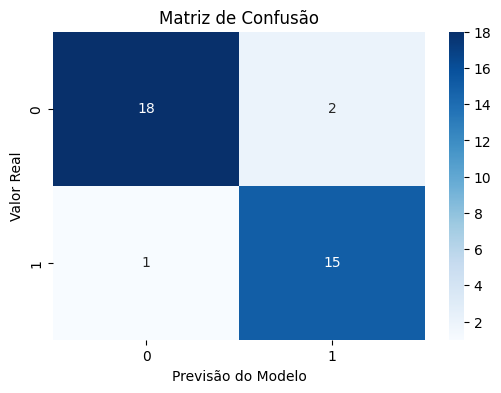

In [25]:
#Matriz de Confusão
matriz_confusao = confusion_matrix(y_teste, y_pred)

# Visualizar em gráfico usando Seaborn e Matplotlib
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.show()

In [26]:
# Extrair TN, FP, FN, TP a partir da confusion_matrix (usando a função ravel)
tn, fp, fn, tp = matriz_confusao.ravel()

# Calcular as métricas exigidas
sensibilidade = tp / (tp + fn)  # Também conhecido como Recall
especificidade = tn / (tn + fp)
fpr = fp / (fp + tn)            # Taxa de Falsos Positivos
fnr = fn / (fn + tp)            # Taxa de Falsos Negativos
acuracia = (tp + tn) / (tp + tn + fp + fn)

print(f"Sensibilidade (Recall): {sensibilidade:.4f}")
print(f"Especificidade: {especificidade:.4f}")
print(f"FPR (Taxa de Falsos Positivos): {fpr:.4f}")
print(f"FNR (Taxa de Falsos Negativos): {fnr:.4f}")
print(f"Acurácia: {acuracia:.4f}")

Sensibilidade (Recall): 0.9375
Especificidade: 0.9000
FPR (Taxa de Falsos Positivos): 0.1000
FNR (Taxa de Falsos Negativos): 0.0625
Acurácia: 0.9167


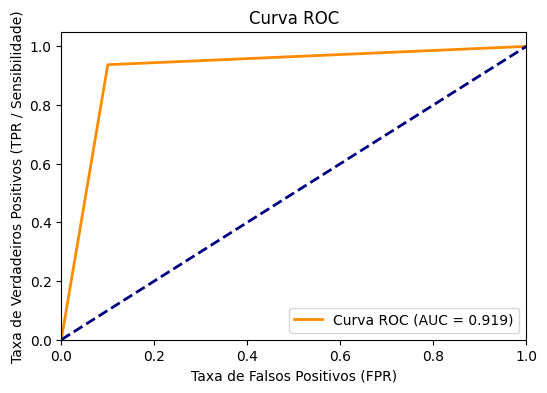

In [27]:
# Inicia variáveis da curva ROC
fpr_roc, tpr_roc, thresholds_roc = roc_curve(y_teste, y_pred)

# Calcular o AUC (Área sob a curva)
auc_valor = roc_auc_score(y_teste, y_pred)

# Visualizar a curva ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr_roc, tpr_roc, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_valor:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR / Sensibilidade)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

**Ajuste de Hiperparâmetros**

In [28]:
#Criação de nova instancia
versao_ajustada = XGBClassifier(random_state=42)

In [29]:
#Definindo parâmetros
h_parametros = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

#Configuração do grid
grid_searchcv = GridSearchCV(
    estimator=versao_ajustada,
    param_grid=h_parametros,
    scoring='roc_auc',
    cv=3,
    verbose=1
)


In [30]:
#Iniciando treinamento
grid_searchcv.fit(x_treino, y_treino)

#Otimização
versao_otimizada = grid_searchcv.best_estimator_


Fitting 3 folds for each of 27 candidates, totalling 81 fits


Resultado do Treinamento

In [33]:
print("Treinamento Concluído\n")
print("Melhores Parâmetros: ", grid_searchcv.best_params_)
print(f"Melhor Score: {grid_searchcv.best_score_:.2f}")

Treinamento Concluído

Melhores Parâmetros:  {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 50}
Melhor Score: 0.97


**INFERÊNCIA**

In [39]:
#Criação de novo conjunto de dados
df_novosdados = df_tratado

In [41]:
#insere novas informações
df_novosdados['departure_hour'] = 10
df_novosdados['day_of_week'] = 3
df_novosdados['airline_JetCloud'] = 1
df_novosdados['origin_GIG'] = 1
df_novosdados['destination_FOR'] = 1
df_novosdados['weather_Clear'] = 1

Dados do Novo Vôo:
     departure_hour  day_of_week  airline_AirOne  airline_FlyFast  \
0                10            3               0                0   
1                10            3               0                0   
2                10            3               0                0   
3                10            3               0                0   
4                10            3               0                0   
..              ...          ...             ...              ...   
115              10            3               0                0   
116              10            3               0                1   
117              10            3               0                0   
118              10            3               1                0   
119              10            3               0                1   

     airline_JetCloud  airline_SkyWings  airline_TravelAir  origin_BSB  \
0                   1                 0                  1           0   
1   

In [42]:
#Transforma em DF
df_novosdados = pd.DataFrame(df_novosdados)

In [44]:
#Mantendo ordem das colunas
df_novosdados = df_novosdados[df_tratado.columns]

df_novosdados.head()

,departure_hour,day_of_week,airline_AirOne,airline_FlyFast,airline_JetCloud,airline_SkyWings,airline_TravelAir,origin_BSB,origin_CNF,origin_GIG,...,destination_BEL,destination_CWB,destination_FOR,destination_REC,destination_SSA,weather_Clear,weather_Fog,weather_Rain,weather_Storm,weather_Wind
0,10,3,0,0,1,0,1,0,0,1,...,0,0,1,0,0,1,0,0,1,0
1,10,3,0,0,1,0,0,0,1,1,...,0,0,1,0,1,1,0,0,0,1
2,10,3,0,0,1,1,0,0,0,1,...,0,0,1,0,1,1,1,0,0,0
3,10,3,0,0,1,0,0,1,0,1,...,0,0,1,0,0,1,0,0,1,0
4,10,3,0,0,1,0,0,0,0,1,...,0,0,1,0,0,1,0,1,0,0


In [48]:
#Criação de variáveis para simulação no cenário
atraso_prob = versao_otimizada.predict_proba(df_novosdados)[:, 1]
previ_atraso = (atraso_prob >= 0.5).astype(int)

print(f"Probabilidade Prevista de Atraso: {atraso_prob[0]*100:.2f}%")
print(f"Previsão de Delay: {previ_atraso[0]*100:.2f}%")

Probabilidade Prevista de Atraso: 3.49%
Previsão de Delay: 0.00%
